# MST Event Boundary Analysis — Encoding Phase
## Data loading, preprocessing, and encoding-phase RT analyses

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, re, warnings
warnings.filterwarnings('ignore')

# Publication-quality figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
})

BASE = Path(r'home/abhishekg/Documents/BRSM_miniproj')
DATA = BASE / 'MST_Data'
print('Base path:', BASE)
print('Data path:', DATA)

Base path: home\abhishekg\Documents\BRSM_miniproj
Data path: home\abhishekg\Documents\BRSM_miniproj\MST_Data


## 1. Helper Functions & Data Loading Pipeline

In [2]:
# ── Helper functions for data preprocessing ──

def load_bin_mapping(filepath):
    """Load lure-bin mapping from a bins.txt file."""
    mapping = {}
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                mapping[int(parts[0])] = int(parts[1])
    return mapping

def extract_item_number(image_path):
    """Extract numeric item ID from image path like Objects\\019a.jpg -> 19."""
    if pd.isna(image_path):
        return None
    cleaned = str(image_path).replace('\\', '/')
    m = re.search(r'(\d+)', os.path.basename(cleaned))
    return int(m.group(1)) if m else None

def classify_item_type(image_path):
    """Classify test item as Target, Lure, or Foil based on filename."""
    if pd.isna(image_path):
        return None
    s = str(image_path).replace('\\', '/')
    if s.lower().startswith('foil'):
        return 'Foil'
    basename = os.path.basename(s)
    if basename.endswith('a.jpg'):
        return 'Target'
    elif basename.endswith('b.jpg'):
        return 'Lure'
    return None

def classify_image_category(image_path):
    """Classify as Object or Scene based on path."""
    if pd.isna(image_path):
        return None
    s = str(image_path).replace('\\', '/').lower()
    if 'scene' in s:
        return 'Scene'
    return 'Object'

def map_response(key):
    """Map key press to response label."""
    if pd.isna(key):
        return None
    k = str(key).strip().lower()
    return {'o': 'Old', 's': 'Similar', 'n': 'New'}.get(k, None)

def map_position(pos):
    """Standardize boundary position labels."""
    if pd.isna(pos):
        return None
    p = str(pos).strip().lower()
    return {'pre': 'Pre', 'post': 'Post', 'mid': 'Mid', 'none': 'Foil'}.get(p, None)

print('Helper functions defined.')

Helper functions defined.


In [3]:
# ── Condition paths ──
CONDITIONS = {
    'Task-Only':  (DATA / 'task_only' / 'task_only_data',
                   DATA / 'task_only' / 'Set6 bins_ob.txt', None),
    'Both':       (DATA / 'Both_item_task' / 'both_data',
                   DATA / 'Both_item_task' / 'Set6 bins.txt',
                   DATA / 'Both_item_task' / 'SetScC bins.txt'),
    'Item-Only':  (DATA / 'item_only' / 'item_only_data',
                   DATA / 'item_only' / 'Set6 bins.txt',
                   DATA / 'item_only' / 'SetScC bins.txt'),
}

def load_condition(data_dir, obj_bin_file, scene_bin_file=None):
    """Load and process all participants for one condition.
    Returns (encoding_df, test_df)."""
    obj_bins = load_bin_mapping(obj_bin_file)
    scene_bins = load_bin_mapping(scene_bin_file) if scene_bin_file else {}

    all_files = sorted(os.listdir(data_dir))
    task_files = [f for f in all_files if '_task_' in f and f.endswith('.csv')]
    test_files = [f for f in all_files if '_test_' in f and f.endswith('.csv')]

    # Keep last file per participant (handles re-runs)
    task_by_id = {f[:5]: f for f in task_files}
    test_by_id = {f[:5]: f for f in test_files}
    valid_ids = sorted(set(task_by_id) & set(test_by_id))

    enc_records, test_records = [], []

    for pid in valid_ids:
        # ── Encoding ──
        tf = pd.read_csv(data_dir / task_by_id[pid])
        trials = tf[tf['trials.thisN'].notna()].copy()
        if len(trials) == 0:
            continue

        trials['participant'] = pid
        trials['block'] = trials['trials.thisN'].astype(int) // 7
        trials['pos_in_block'] = trials['trials.thisN'].astype(int) % 7
        trials['boundary_pos'] = trials['pos_in_block'].map(
            lambda p: 'Post' if p == 0 else ('Pre' if p == 6 else 'Mid'))

        def compute_rt(row):
            if pd.notna(row.get('key_resp_9.rt')):
                return row['key_resp_9.rt'] * 1000
            elif pd.notna(row.get('key_resp_8.rt')):
                return 3000 + row['key_resp_8.rt'] * 1000
            return np.nan
        trials['rt_ms'] = trials.apply(compute_rt, axis=1)

        if 'encoding_task_accuracy' in tf.columns:
            enc_acc = tf['encoding_task_accuracy'].dropna()
            trials['encoding_accuracy'] = enc_acc.iloc[-1] if len(enc_acc) > 0 else np.nan
        else:
            trials['encoding_accuracy'] = np.nan

        enc_records.append(trials[['participant', 'image_path', 'block', 'pos_in_block',
                                   'boundary_pos', 'rt_ms', 'encoding_accuracy',
                                   'key_resp_9.keys', 'key_resp_8.keys']].copy())

        # ── Test ──
        testf = pd.read_csv(data_dir / test_by_id[pid])
        ttrials = testf[testf['image_path'].notna()].copy()
        if len(ttrials) == 0:
            continue

        ttrials['participant'] = pid
        ttrials['item_type'] = ttrials['image_path'].apply(classify_item_type)
        ttrials['position'] = ttrials['position_of_stimuli'].apply(map_position)
        ttrials['response'] = ttrials['key_resp_3.keys'].apply(map_response)
        ttrials['test_rt'] = ttrials['key_resp_3.rt'] * 1000
        ttrials['item_number'] = ttrials['image_path'].apply(extract_item_number)
        ttrials['img_category'] = ttrials['image_path'].apply(classify_image_category)

        def get_bin(row):
            if row['item_type'] != 'Lure':
                return np.nan
            num = row['item_number']
            cat = row['img_category']
            if cat == 'Scene' and num in scene_bins:
                return scene_bins[num]
            if num in obj_bins:
                return obj_bins[num]
            return np.nan
        ttrials['lure_bin'] = ttrials.apply(get_bin, axis=1)

        test_records.append(ttrials[['participant', 'image_path', 'item_type', 'position',
                                     'response', 'test_rt', 'item_number', 'img_category',
                                     'lure_bin']].copy())

    enc_df = pd.concat(enc_records, ignore_index=True) if enc_records else pd.DataFrame()
    test_df = pd.concat(test_records, ignore_index=True) if test_records else pd.DataFrame()
    return enc_df, test_df

# Load all conditions
all_enc = {}
all_test = {}
for cond, (ddir, obj_bins_f, scene_bins_f) in CONDITIONS.items():
    enc, tst = load_condition(ddir, obj_bins_f, scene_bins_f)
    all_enc[cond] = enc
    all_test[cond] = tst
    n_parts = enc['participant'].nunique() if len(enc) > 0 else 0
    n_test = tst['participant'].nunique() if len(tst) > 0 else 0
    print(f'{cond}: {n_parts} participants (encoding), {n_test} (test), '
          f'{len(enc)} encoding trials, {len(tst)} test trials')

Task-Only: 53 participants (encoding), 53 (test), 14840 encoding trials, 7950 test trials
Both: 49 participants (encoding), 49 (test), 13720 encoding trials, 7350 test trials
Item-Only: 56 participants (encoding), 56 (test), 15680 encoding trials, 8400 test trials


## 2. Encoding RT by Boundary Position (Manipulation Check)

This analysis checks whether event boundaries were successfully perceived by participants.  
We expect elevated RT at post-boundary positions (first item after a context shift).

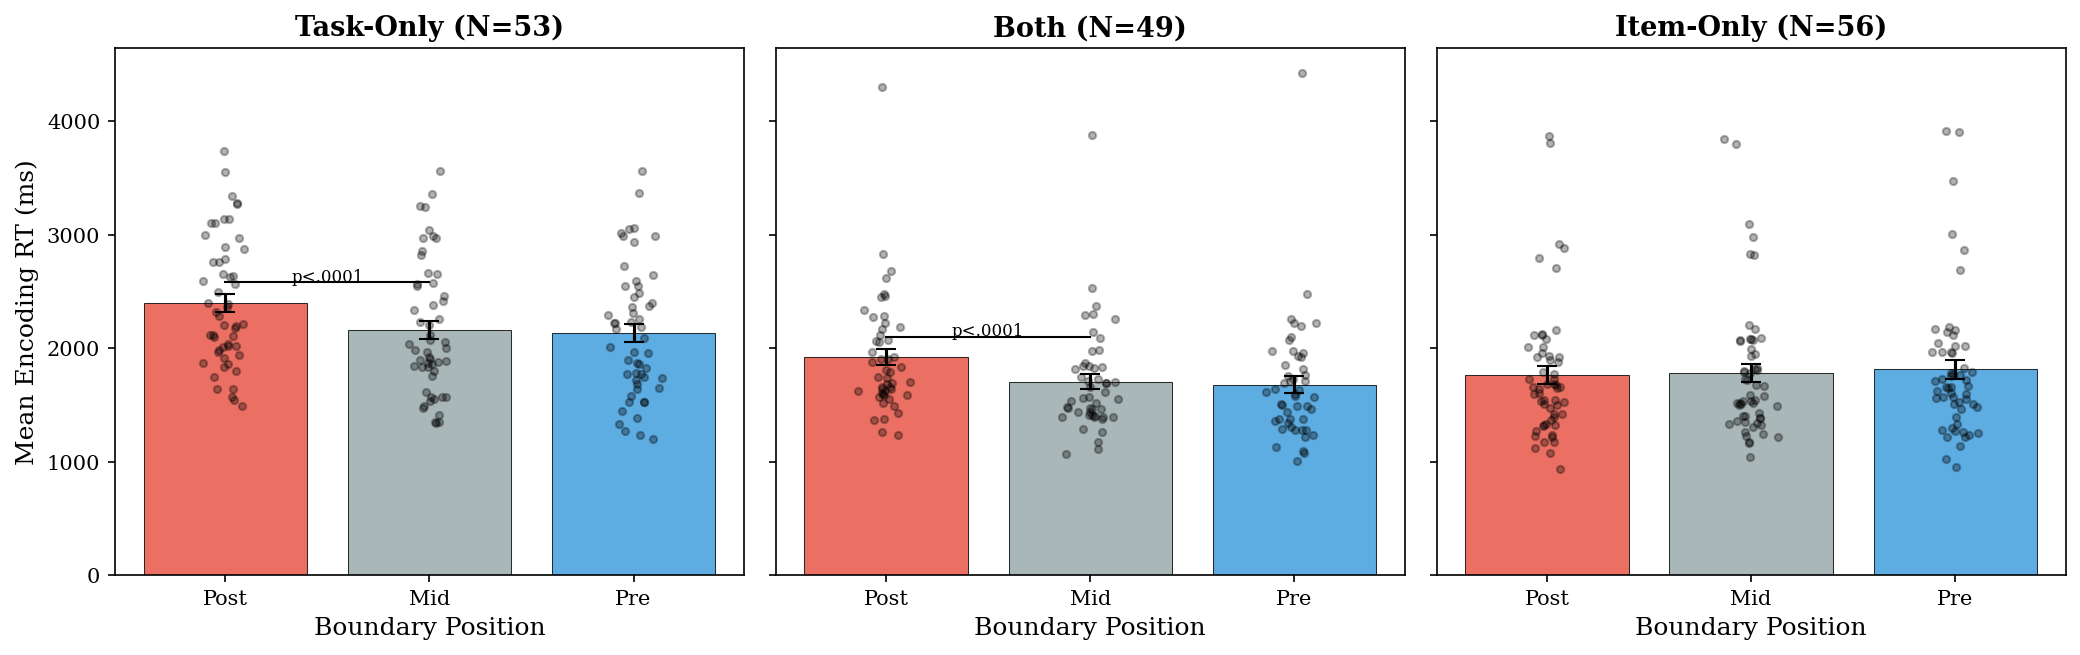


=== Task-Only (N=53) ===
  Post: M=2399.1, SD=561.9
  Mid:  M=2163.5, SD=581.0
  Pre:  M=2131.6, SD=575.8
  Post vs Mid: t(52)=9.391, p=0.0000
  Post vs Pre: t(52)=8.506, p=0.0000
  Mid vs Pre:  t(52)=1.414, p=0.1633

=== Both (N=49) ===
  Post: M=1922.3, SD=514.8
  Mid:  M=1702.4, SD=461.2
  Pre:  M=1679.6, SD=531.0
  Post vs Mid: t(48)=10.013, p=0.0000
  Post vs Pre: t(48)=9.315, p=0.0000
  Mid vs Pre:  t(48)=1.116, p=0.2700

=== Item-Only (N=56) ===
  Post: M=1766.5, SD=592.8
  Mid:  M=1782.6, SD=599.4
  Pre:  M=1812.4, SD=623.9
  Post vs Mid: t(55)=-0.848, p=0.4003
  Post vs Pre: t(55)=-1.765, p=0.0831
  Mid vs Pre:  t(55)=-1.433, p=0.1574


In [4]:
# ── Figure 1: Encoding RT by Boundary Position — all three conditions ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
order = ['Post', 'Mid', 'Pre']
colors = {'Post': '#e74c3c', 'Mid': '#95a5a6', 'Pre': '#3498db'}

rt_stats_all = {}
for idx, (cond, enc_df) in enumerate(all_enc.items()):
    ax = axes[idx]
    # Per-participant mean RT by position
    prt = enc_df.groupby(['participant', 'boundary_pos'])['rt_ms'].mean().reset_index()
    prt_wide = prt.pivot(index='participant', columns='boundary_pos', values='rt_ms')
    
    means = [prt_wide[p].mean() for p in order]
    sems = [prt_wide[p].sem() for p in order]
    
    bars = ax.bar(order, means, yerr=sems, capsize=5,
                  color=[colors[p] for p in order], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Jittered individual data points
    for i, pos in enumerate(order):
        vals = prt_wide[pos].dropna().values
        jitter = np.random.normal(0, 0.05, size=len(vals))
        ax.scatter([i + j for j in jitter], vals, color='black', alpha=0.3, s=12, zorder=5)
    
    ax.set_title(f'{cond} (N={prt_wide.shape[0]})', fontweight='bold')
    ax.set_ylabel('Mean Encoding RT (ms)' if idx == 0 else '')
    ax.set_xlabel('Boundary Position')
    
    # Pairwise t-tests
    t_pm, p_pm = stats.ttest_rel(prt_wide['Post'], prt_wide['Mid'])
    t_pp, p_pp = stats.ttest_rel(prt_wide['Post'], prt_wide['Pre'])
    t_mp, p_mp = stats.ttest_rel(prt_wide['Mid'], prt_wide['Pre'])
    rt_stats_all[cond] = {
        'N': prt_wide.shape[0],
        'Post_M': prt_wide['Post'].mean(), 'Post_SD': prt_wide['Post'].std(),
        'Mid_M': prt_wide['Mid'].mean(), 'Mid_SD': prt_wide['Mid'].std(),
        'Pre_M': prt_wide['Pre'].mean(), 'Pre_SD': prt_wide['Pre'].std(),
        'Post_vs_Mid': (t_pm, p_pm),
        'Post_vs_Pre': (t_pp, p_pp),
        'Mid_vs_Pre': (t_mp, p_mp),
    }
    
    # Significance annotations
    y_max = max(means) + max(sems) + 100
    if p_pm < 0.05:
        ax.plot([0, 1], [y_max, y_max], 'k-', lw=1)
        ax.text(0.5, y_max + 10, f'p={p_pm:.4f}' if p_pm > 0.0001 else 'p<.0001',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(BASE / 'fig1_encoding_rt.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig1_encoding_rt.png', bbox_inches='tight')
plt.show()

# Print stats
for cond, s in rt_stats_all.items():
    print(f"\n=== {cond} (N={s['N']}) ===")
    print(f"  Post: M={s['Post_M']:.1f}, SD={s['Post_SD']:.1f}")
    print(f"  Mid:  M={s['Mid_M']:.1f}, SD={s['Mid_SD']:.1f}")
    print(f"  Pre:  M={s['Pre_M']:.1f}, SD={s['Pre_SD']:.1f}")
    t, p = s['Post_vs_Mid']
    print(f"  Post vs Mid: t({s['N']-1})={t:.3f}, p={p:.4f}")
    t, p = s['Post_vs_Pre']
    print(f"  Post vs Pre: t({s['N']-1})={t:.3f}, p={p:.4f}")
    t, p = s['Mid_vs_Pre']
    print(f"  Mid vs Pre:  t({s['N']-1})={t:.3f}, p={p:.4f}")

## 3. Encoding RT by Within-Block Serial Position

This plot shows how encoding RT varies across the 7 serial positions within each block.  
Position 0 is immediately after a boundary (post), position 6 is right before the next boundary (pre).

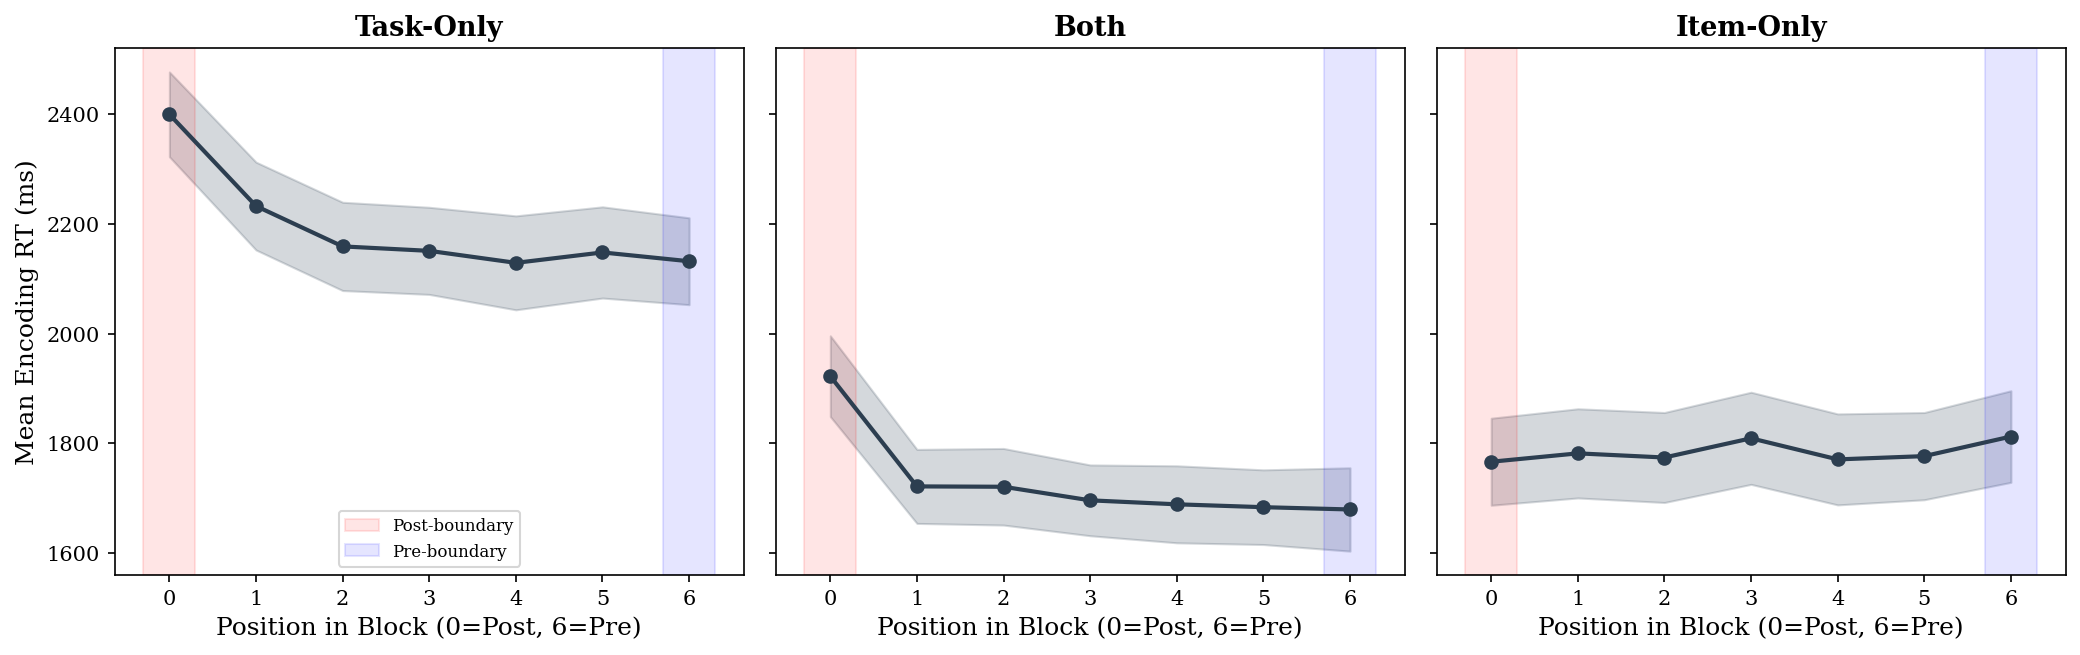

In [5]:
# ── Figure 10: Encoding RT by within-block serial position ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, (cond, enc_df) in enumerate(all_enc.items()):
    ax = axes[idx]
    
    # Per-participant mean RT by position in block
    prt = enc_df.groupby(['participant', 'pos_in_block'])['rt_ms'].mean().reset_index()
    summary = prt.groupby('pos_in_block')['rt_ms'].agg(['mean', 'sem']).reset_index()
    
    ax.plot(summary['pos_in_block'], summary['mean'], 'o-', color='#2c3e50', linewidth=2)
    ax.fill_between(summary['pos_in_block'],
                    summary['mean'] - summary['sem'],
                    summary['mean'] + summary['sem'],
                    alpha=0.2, color='#2c3e50')
    
    # Shade post-boundary and pre-boundary positions
    ax.axvspan(-0.3, 0.3, alpha=0.1, color='red', label='Post-boundary')
    ax.axvspan(5.7, 6.3, alpha=0.1, color='blue', label='Pre-boundary')
    
    ax.set_xlabel('Position in Block (0=Post, 6=Pre)')
    ax.set_ylabel('Mean Encoding RT (ms)' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_xticks(range(7))
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(BASE / 'fig10_serial_position_rt.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig10_serial_position_rt.png', bbox_inches='tight')
plt.show()

## 4. Encoding RT Distributions (Violin Plots)

Violin plots provide a richer view of the RT distributions at each boundary position,  
complementing the bar-chart summary above.

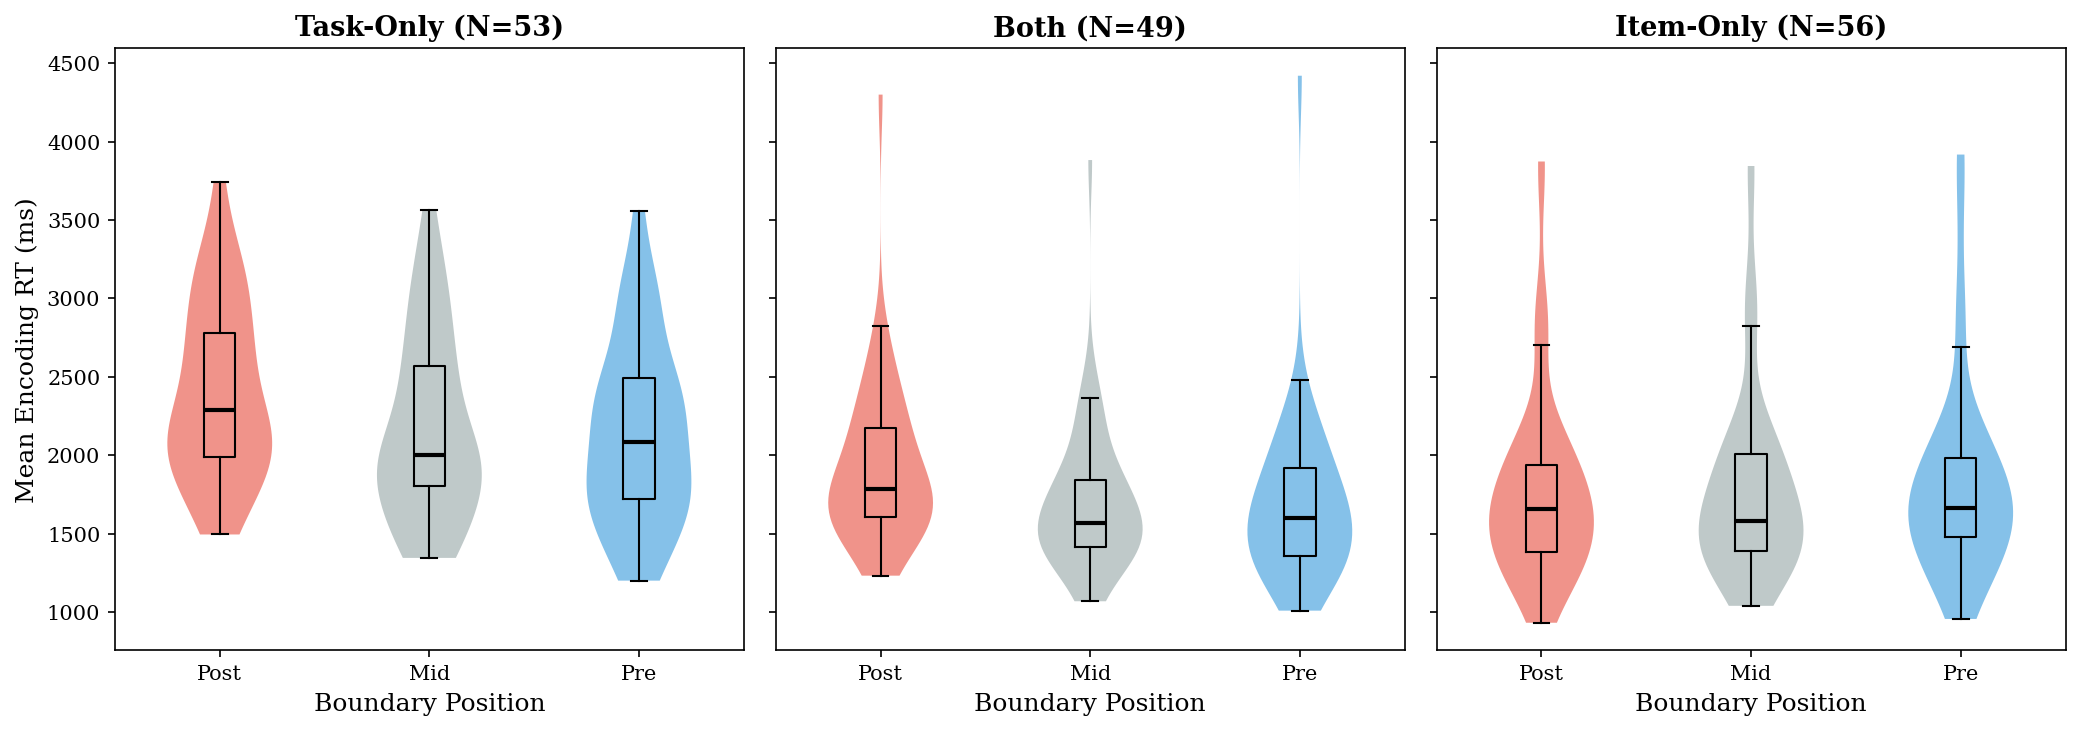

In [6]:
# ── Figure 11: Encoding RT violin plots by boundary position ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
violin_colors = {'Post': '#e74c3c', 'Mid': '#95a5a6', 'Pre': '#3498db'}

for idx, (cond, enc_df) in enumerate(all_enc.items()):
    ax = axes[idx]
    prt = enc_df.groupby(['participant', 'boundary_pos'])['rt_ms'].mean().reset_index()
    
    positions_list = ['Post', 'Mid', 'Pre']
    plot_data = [prt[prt['boundary_pos'] == pos]['rt_ms'].dropna().values
                 for pos in positions_list]
    
    parts = ax.violinplot(plot_data, positions=[0, 1, 2], showmeans=False,
                          showmedians=False, showextrema=False)
    for i, (pc, pos) in enumerate(zip(parts['bodies'], positions_list)):
        pc.set_facecolor(violin_colors[pos])
        pc.set_alpha(0.6)
    
    # Overlay box plot
    bp = ax.boxplot(plot_data, positions=[0, 1, 2], widths=0.15, patch_artist=False,
                    showfliers=False, medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1))
    
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(positions_list)
    ax.set_ylabel('Mean Encoding RT (ms)' if idx == 0 else '')
    ax.set_title(f'{cond} (N={prt["participant"].nunique()})', fontweight='bold')
    ax.set_xlabel('Boundary Position')

plt.tight_layout()
plt.savefig(BASE / 'fig11_encoding_rt_violin.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig11_encoding_rt_violin.png', bbox_inches='tight')
plt.show()

## 5. Encoding Accuracy Summary

In [7]:
# ── Encoding accuracy across conditions ──
print('=== Encoding Accuracy Summary ===')
for cond, enc_df in all_enc.items():
    acc = enc_df.groupby('participant')['encoding_accuracy'].first()
    print(f'{cond} (N={len(acc)}): M={acc.mean():.3f}, SD={acc.std():.3f}, '
          f'Range=[{acc.min():.3f}, {acc.max():.3f}]')

=== Encoding Accuracy Summary ===
Task-Only (N=53): M=0.943, SD=0.042, Range=[0.830, 1.000]
Both (N=49): M=0.947, SD=0.032, Range=[0.815, 0.994]
Item-Only (N=56): M=0.801, SD=0.032, Range=[0.711, 0.863]


## 6. Encoding Phase — Statistical Summary for Report

In [8]:
# ── Detailed encoding-phase stats for report ──
print('=' * 70)
print('ENCODING PHASE SUMMARY')
print('=' * 70)

for cond in ['Task-Only', 'Both', 'Item-Only']:
    enc_df = all_enc[cond]
    N = enc_df['participant'].nunique()
    print(f'\n{"="*45}')
    print(f'CONDITION: {cond} (N={N})')
    print(f'{"="*45}')

    # Encoding accuracy
    acc = enc_df.groupby('participant')['encoding_accuracy'].first()
    print(f'Encoding Accuracy: M={acc.mean():.3f}, SD={acc.std():.3f}')

    # Encoding RT
    print('\nEncoding RT (ms):')
    for pos in ['Post', 'Mid', 'Pre']:
        prt = enc_df[enc_df['boundary_pos'] == pos].groupby('participant')['rt_ms'].mean()
        print(f'  {pos}: M={prt.mean():.1f}, SD={prt.std():.1f}')

    # Pairwise tests
    s = rt_stats_all[cond]
    t, p = s['Post_vs_Mid']
    print(f'  Post vs Mid: t({N-1})={t:.3f}, p={p:.6f}')
    t, p = s['Post_vs_Pre']
    print(f'  Post vs Pre: t({N-1})={t:.3f}, p={p:.6f}')
    t, p = s['Mid_vs_Pre']
    print(f'  Mid vs Pre:  t({N-1})={t:.3f}, p={p:.6f}')

ENCODING PHASE SUMMARY

CONDITION: Task-Only (N=53)
Encoding Accuracy: M=0.943, SD=0.042

Encoding RT (ms):
  Post: M=2399.1, SD=561.9
  Mid: M=2163.5, SD=581.0
  Pre: M=2131.6, SD=575.8
  Post vs Mid: t(52)=9.391, p=0.000000
  Post vs Pre: t(52)=8.506, p=0.000000
  Mid vs Pre:  t(52)=1.414, p=0.163277

CONDITION: Both (N=49)
Encoding Accuracy: M=0.947, SD=0.032

Encoding RT (ms):
  Post: M=1922.3, SD=514.8
  Mid: M=1702.4, SD=461.2
  Pre: M=1679.6, SD=531.0
  Post vs Mid: t(48)=10.013, p=0.000000
  Post vs Pre: t(48)=9.315, p=0.000000
  Mid vs Pre:  t(48)=1.116, p=0.270015

CONDITION: Item-Only (N=56)
Encoding Accuracy: M=0.801, SD=0.032

Encoding RT (ms):
  Post: M=1766.5, SD=592.8
  Mid: M=1782.6, SD=599.4
  Pre: M=1812.4, SD=623.9
  Post vs Mid: t(55)=-0.848, p=0.400320
  Post vs Pre: t(55)=-1.765, p=0.083059
  Mid vs Pre:  t(55)=-1.433, p=0.157428
